# WP1 — permutation convergence: why N = 500 is enough

Reviewer minor comment 1: *"The number of random permutations is stated as 500 in the
Results and Discussion but as 1000 in the Methods. Please unify this and justify the
chosen number."*

Decision **D1**: N = 500 is what was actually run (501 files in the legacy store), the
Methods number was a drafting error, and the Methods are corrected **down** to 500.
This notebook produces the figure that *demonstrates* the justification instead of
asserting it.

**The argument.** The permutation background is a **bias correction**, not the
significance test. Raw Fisher odds ratios scale with element length, so SINEs (~300 bp)
would be systematically under-called and LINEs/LTRs (~6 kb) over-called; the permutation
distribution exists to produce the observed/random OR ratio. Significance comes from the
FDR-adjusted Fisher exact test. What N therefore has to deliver is a **stable mean and SD
of the random OR** — not a small empirical p floor. This notebook shows both are stable
long before 500.

Reads the compacted store from `01b_compact_permutation_results.py` (WP1b) — the 6.37 GB
`consolidated_random_data.csv` the frozen notebook used no longer exists.

**Writes** `svg/S14A_permutation_convergence_classes.svg`,
`svg/S14B_permutation_convergence_families.svg`,
`svg/S14C_permutation_convergence_error.svg` → new Supplementary Figure S14.

In [1]:
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath("."))
import revision_lib as rl

# Reused so the contingency table and the genome-wide totals are identical to the ones
# the enrichment tables were built with, rather than re-derived here.
window_sensitivity = importlib.import_module("05b_window_sensitivity")

N_TSS_10KB = 272_233_268  # published span of the 10 kb window set; == 05b's measurement
N_GENOME = window_sensitivity.N_GENOME

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({"font.size": rl.GLOBAL_FONT_SIZE})
os.makedirs(rl.SVG_DIR, exist_ok=True)
print(f"permutation store: {rl.permutation_store_dir('10kb')}")

permutation store: /home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/output/permutation_counts_10kb


## 1. Per-permutation random odds ratio, per class and per family

One random OR per permutation per group, using exactly the contingency table of the
published analysis: `[[k, N_TSS - k], [K - k, (N_GENOME - N_TSS) - (K - k)]]` where `k`
is the number of elements of that group falling in the shuffled TSS windows and `K` its
genome-wide total.

In [2]:
def random_or_by_permutation(level):
    """Random OR per permutation for every group at `level` ('class_name'/'family_name')."""
    genome = window_sensitivity.genome_counts_by(level)
    totals = rl.permutation_totals(window="10kb", by=level)
    wide = totals.pivot(index="seed", columns=level, values="n").fillna(0).sort_index()

    out = {}
    for name in wide.columns:
        if name not in genome or not str(name).strip():
            continue
        K = genome[name]
        k = wide[name].to_numpy(dtype=float)
        a, b = k, N_TSS_10KB - k
        c, d = K - k, (N_GENOME - N_TSS_10KB) - (K - k)
        with np.errstate(divide="ignore", invalid="ignore"):
            out[name] = (a * d) / (b * c)
    return pd.DataFrame(out, index=wide.index)


or_classes = random_or_by_permutation("class_name")
or_families = random_or_by_permutation("family_name")
print(f"classes  {or_classes.shape[1]} groups x {or_classes.shape[0]} permutations")
print(f"families {or_families.shape[1]} groups x {or_families.shape[0]} permutations")
or_classes.describe().T[["mean", "std", "min", "max"]].round(4)

classes  6 groups x 500 permutations
families 44 groups x 500 permutations


,mean,std,min,max
DNA,1.6051,0.0098,1.5733,1.6389
LINE,2.4255,0.0094,2.3864,2.4564
LTR,1.6667,0.0099,1.6400,1.7003
RC,1.6138,0.1629,1.1619,2.0781
Retroposon,1.7507,0.0941,1.4968,2.0265
SINE,1.5346,0.0053,1.5193,1.5558


## 2. Running mean and running SD

The quantities the enrichment tables actually consume. If these are flat well before the
right-hand edge, N = 500 is not a limiting choice.

In [3]:
def running_stats(frame):
    running_mean = frame.expanding().mean()
    running_sd = frame.expanding().std(ddof=1)
    return running_mean, running_sd


mean_classes, sd_classes = running_stats(or_classes)
mean_families, sd_families = running_stats(or_families)

# Table 1 reports the random-OR mean and SD at N = 500; these must match it.
summary = pd.DataFrame(
    {
        "random_OR_mean_N500": or_classes.mean(),
        "random_OR_SD_N500": or_classes.std(ddof=1),
        "mean_at_N100": mean_classes.loc[100],
        "mean_at_N250": mean_classes.loc[250],
        "drift_N100_to_N500_in_SD": (
            (mean_classes.loc[100] - or_classes.mean()).abs() / or_classes.std(ddof=1)
        ),
        "drift_N250_to_N500_in_SD": (
            (mean_classes.loc[250] - or_classes.mean()).abs() / or_classes.std(ddof=1)
        ),
    }
).round(4)
summary

,random_OR_mean_N500,random_OR_SD_N500,mean_at_N100,mean_at_N250,drift_N100_to_N500_in_SD,drift_N250_to_N500_in_SD
DNA,1.6051,0.0098,1.6066,1.6052,0.1516,0.0004
LINE,2.4255,0.0094,2.4261,2.4258,0.0549,0.0237
LTR,1.6667,0.0099,1.6685,1.6673,0.1795,0.0586
RC,1.6138,0.1629,1.6315,1.6150,0.1089,0.0074
Retroposon,1.7507,0.0941,1.7387,1.7466,0.1275,0.0439
SINE,1.5346,0.0053,1.5351,1.5343,0.0843,0.0582


## 3. Panel A — running mean of the random OR, per class

Plotted as a fraction of the final (N = 500) value so six classes with very different
absolute ORs share one axis. The grey band is ±1 %.

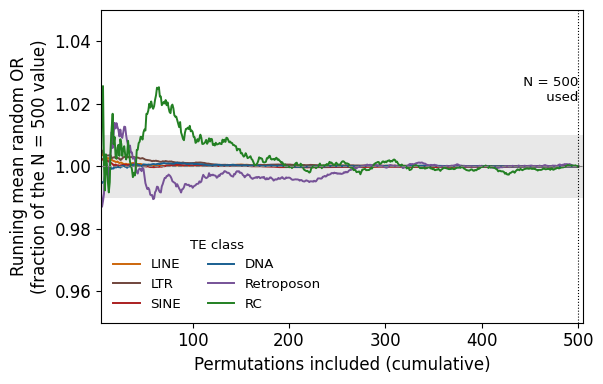

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 4.0))

for class_name in rl.CLASS_NAMES:
    if class_name not in mean_classes.columns:
        continue
    series = mean_classes[class_name] / or_classes[class_name].mean()
    ax.plot(series.index, series.to_numpy(), lw=1.4,
            color=rl.CLASS_PALETTE_SHORT[class_name], label=class_name)

ax.axhspan(0.99, 1.01, color="grey", alpha=0.18, lw=0, zorder=0)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.axvline(500, color="black", lw=0.8, ls=":")
ax.text(500, ax.get_ylim()[1], " N = 500\n used", va="top", ha="right", fontsize=rl.fs(8))
ax.set_xlabel("Permutations included (cumulative)")
ax.set_ylabel("Running mean random OR\n(fraction of the N = 500 value)")
ax.set_xlim(5, 505)
ax.set_ylim(0.95, 1.05)
ax.legend(title="TE class", frameon=False, fontsize=rl.fs(8), title_fontsize=rl.fs(8), ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S14A_permutation_convergence_classes.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 4. Panel B — running SD of the random OR, per class

The SD is the harder quantity to stabilise, so it is the one that decides the answer.

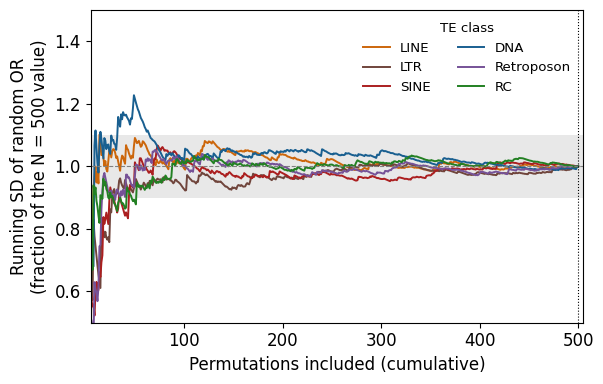

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4.0))

for class_name in rl.CLASS_NAMES:
    if class_name not in sd_classes.columns:
        continue
    series = sd_classes[class_name] / or_classes[class_name].std(ddof=1)
    ax.plot(series.index, series.to_numpy(), lw=1.4,
            color=rl.CLASS_PALETTE_SHORT[class_name], label=class_name)

ax.axhspan(0.9, 1.1, color="grey", alpha=0.18, lw=0, zorder=0)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.axvline(500, color="black", lw=0.8, ls=":")
ax.set_xlabel("Permutations included (cumulative)")
ax.set_ylabel("Running SD of random OR\n(fraction of the N = 500 value)")
ax.set_xlim(5, 505)
ax.set_ylim(0.5, 1.5)
ax.legend(title="TE class", frameon=False, fontsize=rl.fs(8), title_fontsize=rl.fs(8), ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S14B_permutation_convergence_sd_classes.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 5. Panel C — all 44 families, as absolute drift in units of their own SD

The single number that answers the reviewer: how far the running mean at N would still
move before N = 500, expressed in standard deviations of the random OR. One faint line
per family, the median across families in black.

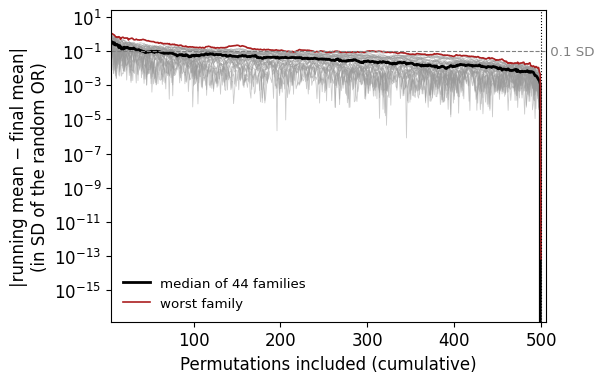

In [6]:
final_mean = or_families.mean()
final_sd = or_families.std(ddof=1)
drift = (mean_families - final_mean).abs() / final_sd
drift = drift.loc[:, final_sd > 0]

fig, ax = plt.subplots(figsize=(6.2, 4.0))
for family_name in drift.columns:
    ax.plot(drift.index, drift[family_name].to_numpy(), lw=0.6, color="#999999", alpha=0.5)
ax.plot(drift.index, drift.median(axis=1).to_numpy(), lw=2.0, color="black",
        label=f"median of {drift.shape[1]} families")
ax.plot(drift.index, drift.max(axis=1).to_numpy(), lw=1.2, color="#ab1f20",
        label="worst family")

ax.axhline(0.1, color="grey", lw=0.8, ls="--")
ax.text(505, 0.1, " 0.1 SD", va="center", fontsize=rl.fs(8), color="grey")
ax.axvline(500, color="black", lw=0.8, ls=":")
ax.set_yscale("log")
ax.set_xlabel("Permutations included (cumulative)")
ax.set_ylabel("|running mean − final mean|\n(in SD of the random OR)")
ax.set_xlim(5, 505)
ax.legend(frameon=False, fontsize=rl.fs(8))
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S14C_permutation_convergence_families.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 6. The numbers to quote in the Methods justification

In [7]:
checkpoints = [50, 100, 200, 250, 300, 400]
rows = []
for n in checkpoints:
    rows.append(
        {
            "N": n,
            "max_class_mean_drift_SD": float(
                ((mean_classes.loc[n] - or_classes.mean()).abs()
                 / or_classes.std(ddof=1)).max()
            ),
            "max_family_mean_drift_SD": float(drift.loc[n].max()),
            "median_family_mean_drift_SD": float(drift.loc[n].median()),
            "max_class_SD_ratio_error": float(
                ((sd_classes.loc[n] / or_classes.std(ddof=1)) - 1).abs().max()
            ),
        }
    )
convergence_table = pd.DataFrame(rows).round(4)
convergence_table.to_csv(
    os.path.join(rl.OUTPUT_DIR, "permutation_convergence_checkpoints.csv"), index=False
)
print("empirical p floor at N = 500: 2/501 =", round(rl.EMPIRICAL_P_FLOOR, 6))
convergence_table

empirical p floor at N = 500: 2/501 = 0.003992


,N,max_class_mean_drift_SD,max_family_mean_drift_SD,median_family_mean_drift_SD,max_class_SD_ratio_error
0,50,0.3929,0.3814,0.0945,0.2155
1,100,0.1795,0.1708,0.0577,0.0730
2,200,0.0951,0.1138,0.0426,0.0470
3,250,0.0586,0.0998,0.0348,0.0393
4,300,0.0502,0.1016,0.0270,0.0497
5,400,0.0464,0.0516,0.0128,0.0227


## 7. SVGs written, and where each one goes

Panel letters and placement are Daniil's manual Figma step — see `svg/PLACEMENT.md`.

In [8]:
for name in sorted(os.listdir(rl.SVG_DIR)):
    if name.startswith("S14"):
        path = os.path.join(rl.SVG_DIR, name)
        print(f"  {name:52s} {os.path.getsize(path):>8,} B   -> new Supplementary Figure S14")

  S14A_permutation_convergence_classes.svg               51,543 B   -> new Supplementary Figure S14
  S14B_permutation_convergence_sd_classes.svg            68,900 B   -> new Supplementary Figure S14
  S14C_permutation_convergence_families.svg             509,166 B   -> new Supplementary Figure S14
